# Détection de fraude sur paiements en ligne

**Angle décisionnel** — support aux équipes risque : bloquer les transactions
suspectes **sans pénaliser les clients légitimes**, et choisir le seuil de
décision à partir d'un **coût métier** explicite plutôt que d'une convention
statistique.

**Données** — dataset ULB *Credit Card Fraud Detection* (Dal Pozzolo et al.) :
284 807 transactions réelles de cartes européennes (sept. 2013), dont **492
fraudes (0,173 %)**. Les features V1–V28 sont des composantes PCA anonymisées ;
seule `Amount` est brute. Téléchargé de façon reproductible depuis OpenML
(`data_id=1597`), sans compte.

**Plan du notebook**
1. Chargement & déséquilibre extrême
2. EDA — montants, séparabilité des composantes
3. Stratégies de rééquilibrage (comparaison contrôlée)
4. Supervisé vs non-supervisé
5. Seuil de décision coût-sensible
6. Interprétabilité SHAP
7. Conclusions & limites

> La logique lourde vit dans `src/` (un module par étape) ; ce notebook raconte
> l'histoire et affiche les résultats produits par ces modules.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from data import load_raw, TARGET_COL

sns.set_theme(style="whitegrid")
RNG = np.random.default_rng(42)

df = load_raw()
print(f"{len(df):,} transactions, {df[TARGET_COL].sum()} fraudes "
      f"({df[TARGET_COL].mean()*100:.3f} %)")
df.head()

284,807 transactions, 492 fraudes (0.173 %)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Un déséquilibre extrême — et pourquoi l'accuracy est piégeuse

577 transactions légitimes pour **une** fraude : un modèle qui répond
« jamais fraude » atteint 99,83 % d'accuracy en ne détectant rien. Toute
l'évaluation de ce projet repose donc sur le couple **précision / rappel**
(PR-AUC en tête), jamais sur l'accuracy.

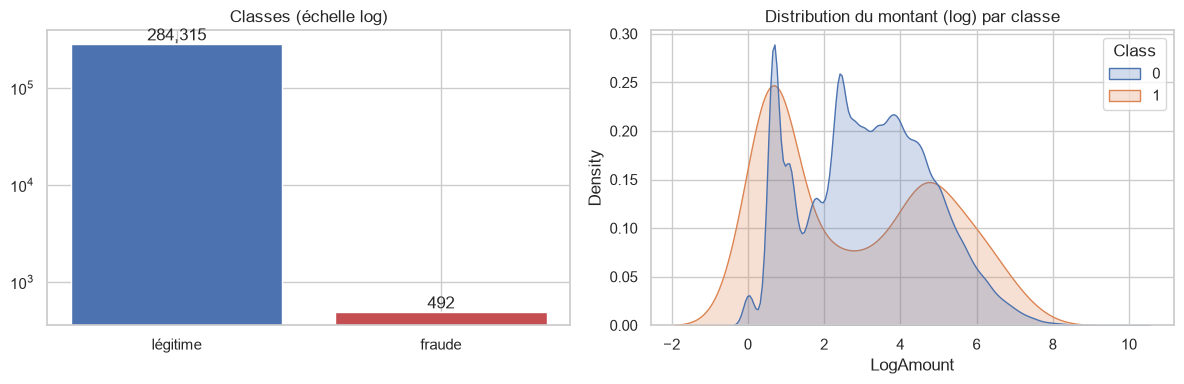

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df[TARGET_COL].value_counts()
axes[0].bar(["légitime", "fraude"], counts.values, color=["#4c72b0", "#c44e52"])
axes[0].set_yscale("log")
axes[0].set_title("Classes (échelle log)")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

sns.kdeplot(data=df.assign(LogAmount=np.log1p(df.Amount)), x="LogAmount",
            hue=TARGET_COL, common_norm=False, fill=True, ax=axes[1])
axes[1].set_title("Distribution du montant (log) par classe")
plt.tight_layout()

Les fraudes ont une distribution de montants plus étalée vers le haut, mais le
recouvrement est fort : **le montant seul ne suffit pas**, ce sont les
composantes PCA qui portent le signal.

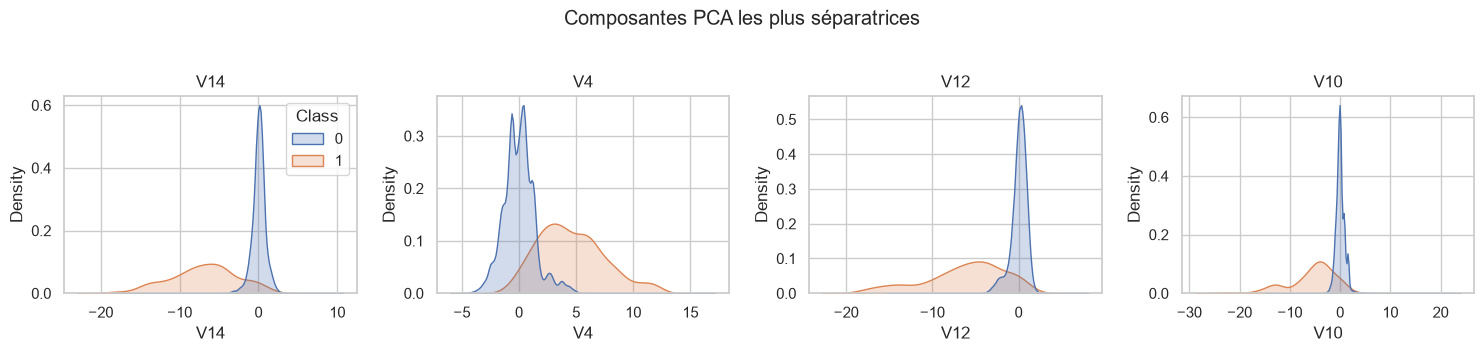

In [3]:
# Séparabilité des composantes les plus discriminantes (identifiées par SHAP §6)
top_v = ["V14", "V4", "V12", "V10"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), sharey=False)
for ax, v in zip(axes, top_v):
    sns.kdeplot(data=df, x=v, hue=TARGET_COL, common_norm=False,
                fill=True, ax=ax, legend=(v == top_v[0]))
    ax.set_title(v)
plt.suptitle("Composantes PCA les plus séparatrices", y=1.03)
plt.tight_layout()

## 2. Le rééquilibrage change le *seuil*, pas le *classement*

Protocole contrôlé : **même modèle** (régression logistique), on ne fait varier
que la stratégie de gestion du déséquilibre — aucune (baseline), pondération de
classe, sous-échantillonnage, SMOTE, SMOTE+Tomek. Le rééchantillonnage est
appliqué **dans un pipeline imblearn**, donc uniquement sur l'entraînement,
jamais sur le test.

,model,PR_AUC,ROC_AUC,precision,recall,f1,threshold,TP,FP,FN,TN
0,none,0.715,0.962,0.846,0.626,0.720,0.5,77,14,46,71065
1,SMOTE+Tomek,0.710,0.972,0.057,0.894,0.107,0.5,110,1816,13,69263
2,SMOTE,0.710,0.972,0.057,0.894,0.107,0.5,110,1816,13,69263
3,class_weight,0.702,0.971,0.060,0.886,0.112,0.5,109,1711,14,69368
4,undersample,0.686,0.971,0.043,0.902,0.081,0.5,111,2490,12,68589


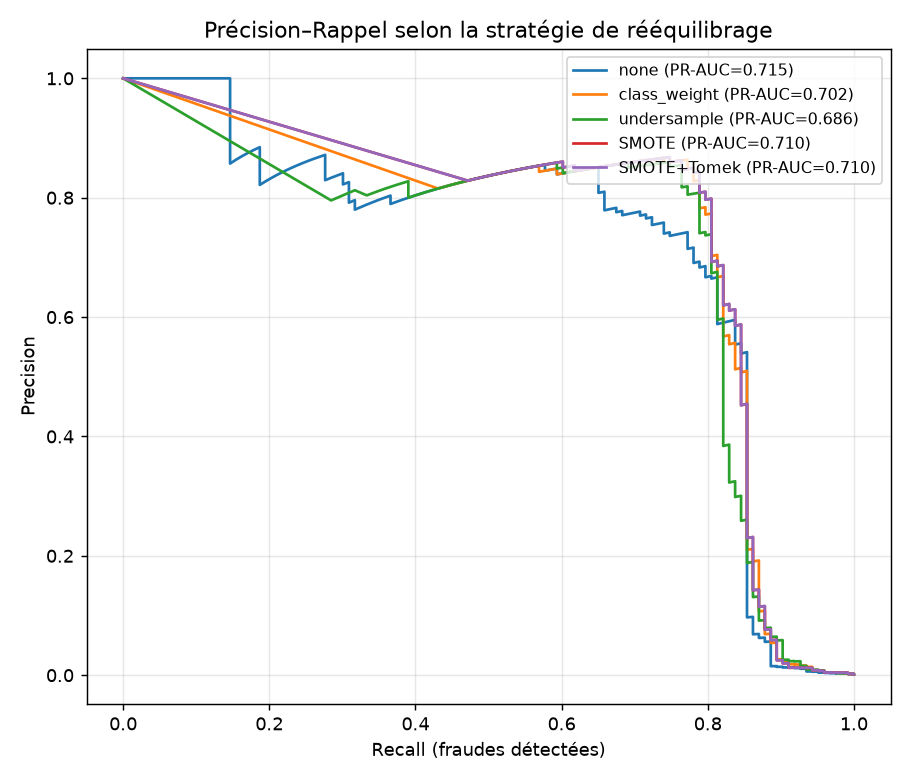

In [4]:
resamp = pd.read_csv(ROOT / "reports" / "resampling_comparison.csv")
display(resamp.round(3))
display(Image(ROOT / "reports" / "figures" / "resampling_pr_curves.png",
              width=640))

**Lecture** — le PR-AUC (qualité du *classement* des transactions) bouge à
peine (~0,69–0,72) : le rééquilibrage ne crée pas d'information. En revanche,
au seuil fixe de 0,5, il déplace radicalement le compromis : la baseline est
précise mais rate 37 % des fraudes ; les variantes rééquilibrées rappellent
~89 % des fraudes au prix de ~1 700–2 500 fausses alertes. **Le vrai levier est
donc le choix du seuil** — traité en §4 avec un coût métier.

## 3. Supervisé vs non-supervisé

Trois modèles supervisés (régression logistique pondérée, forêt aléatoire,
XGBoost avec `scale_pos_weight`) et un détecteur d'anomalies **non supervisé**
(Isolation Forest, entraîné sans étiquettes) évalués sur le même test.

,model,PR_AUC,ROC_AUC,precision,recall,f1,threshold,TP,FP,FN,TN
0,XGBoost,0.858,0.978,0.893,0.813,0.851,0.500,100,12,23,71067
1,RandomForest (balanced),0.836,0.945,0.967,0.724,0.828,0.500,89,3,34,71076
2,LogReg (balanced),0.702,0.971,0.060,0.886,0.112,0.500,109,1711,14,69368
3,IsolationForest (unsup.),0.165,0.950,0.276,0.276,0.276,0.652,34,89,89,70990


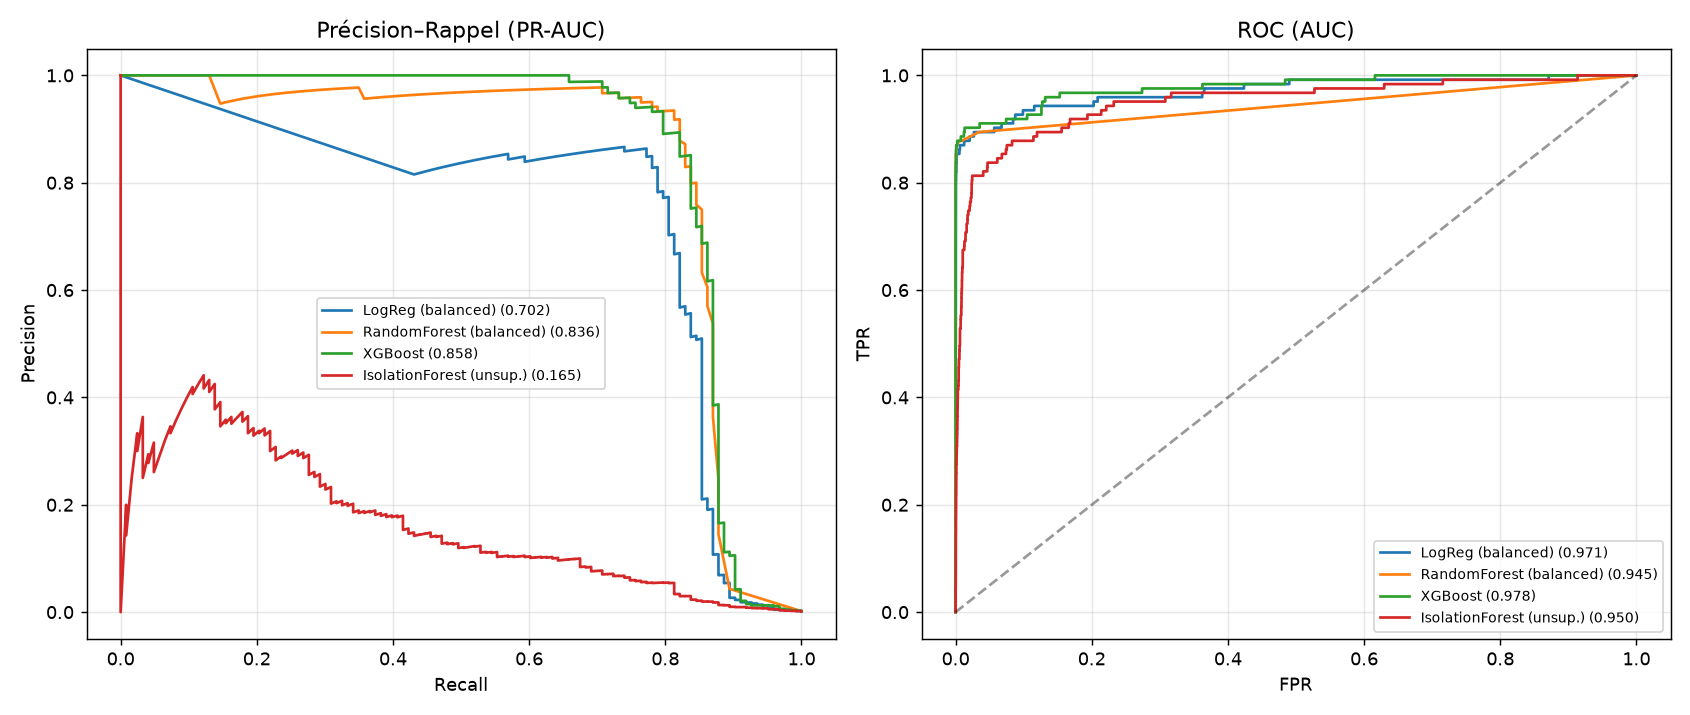

In [5]:
models = pd.read_csv(ROOT / "reports" / "model_comparison.csv")
display(models.round(3))
display(Image(ROOT / "reports" / "figures" / "model_comparison.png", width=900))

**Lecture** — XGBoost domine (PR-AUC **0,86**, précision 89 % / rappel 81 % au
seuil 0,5). L'Isolation Forest est loin derrière en précision (PR-AUC 0,17)
mais son ROC-AUC de 0,95 **sans aucune étiquette** en fait un filet de sécurité
pertinent contre les fraudes *nouvelles*, absentes de l'historique labellisé —
complément, pas concurrent.

## 4. Le seuil de décision comme problème de coût métier

Modèle de coût simple et explicite :

| Événement | Coût |
|---|---|
| Fraude manquée (FN) | montant remboursé de la transaction (min. 50 €) |
| Transaction signalée (TP ou FP) | 5 € de revue analyste |

On balaie le seuil et on cherche le minimum du coût total sur le test.

seuil optimal : 0.130  ->  5,004 EUR (20 fraudes manquées, 121 signalées)
seuil naïf 0.5 : 5,159 EUR (23 manquées, 112 signalées)


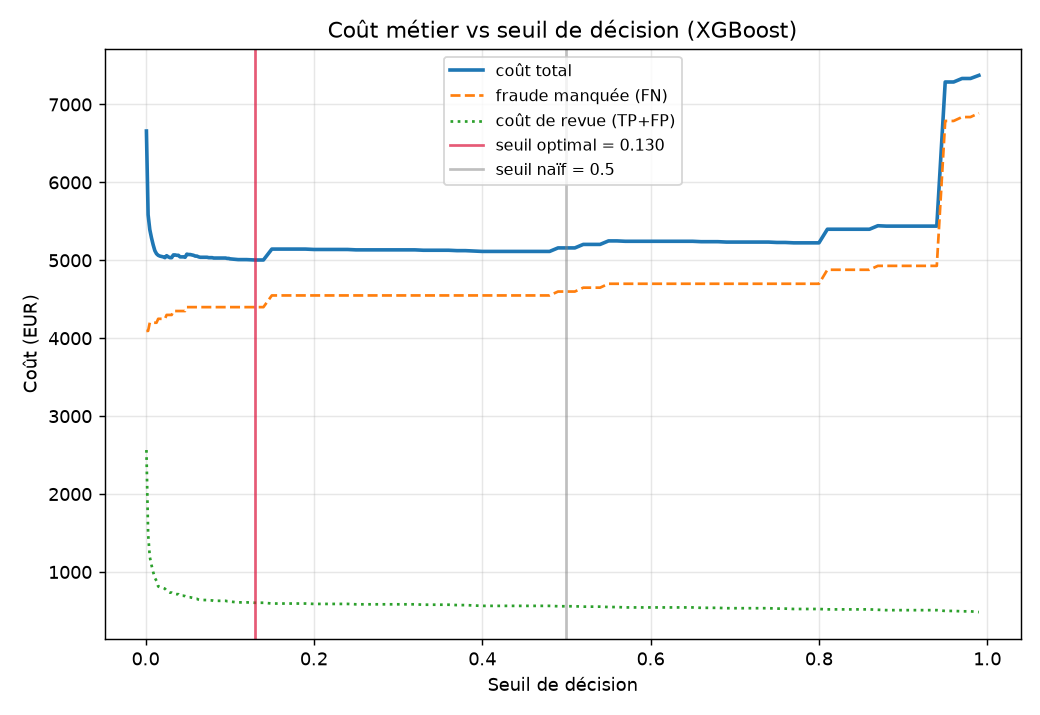

In [6]:
sweep = pd.read_csv(ROOT / "reports" / "cost_threshold_sweep.csv")
best = sweep.loc[sweep.total_cost.idxmin()]
naive = sweep.iloc[(sweep.threshold - 0.5).abs().idxmin()]
print(f"seuil optimal : {best.threshold:.3f}  ->  {best.total_cost:,.0f} EUR "
      f"({best.n_missed:.0f} fraudes manquées, {best.n_flagged:.0f} signalées)")
print(f"seuil naïf 0.5 : {naive.total_cost:,.0f} EUR "
      f"({naive.n_missed:.0f} manquées, {naive.n_flagged:.0f} signalées)")
display(Image(ROOT / "reports" / "figures" / "cost_vs_threshold.png",
              width=640))

**Lecture** — sans modèle, la fraude du test coûterait ≈ 16 600 €. Le modèle au
seuil naïf ramène ce coût à ≈ 5 200 € (–69 %) ; le seuil optimal (≈ 0,13, bien
en dessous de 0,5) gagne encore ~3 % en acceptant quelques alertes de plus. La
forme plate de la courbe autour de l'optimum est une bonne nouvelle
opérationnelle : le choix exact du seuil est **robuste**.

## 5. Interprétabilité — expliquer chaque alerte (SHAP)

Une équipe risque n'agit pas sur un score opaque. TreeSHAP fournit des
attributions exactes par transaction pour XGBoost.

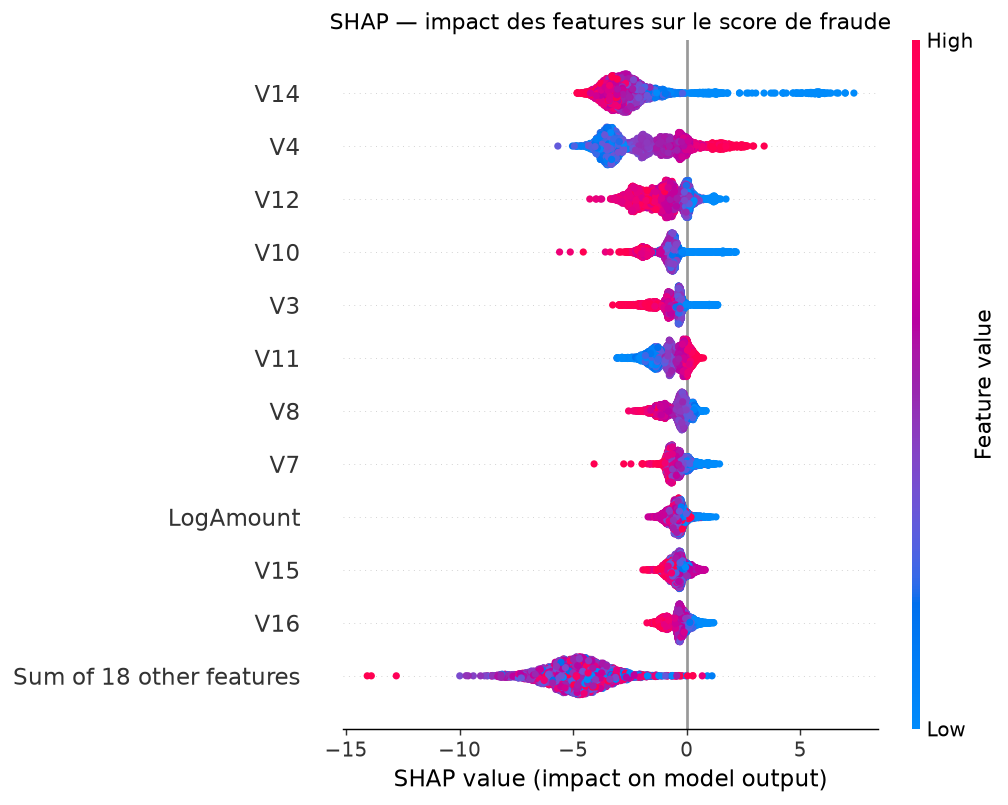

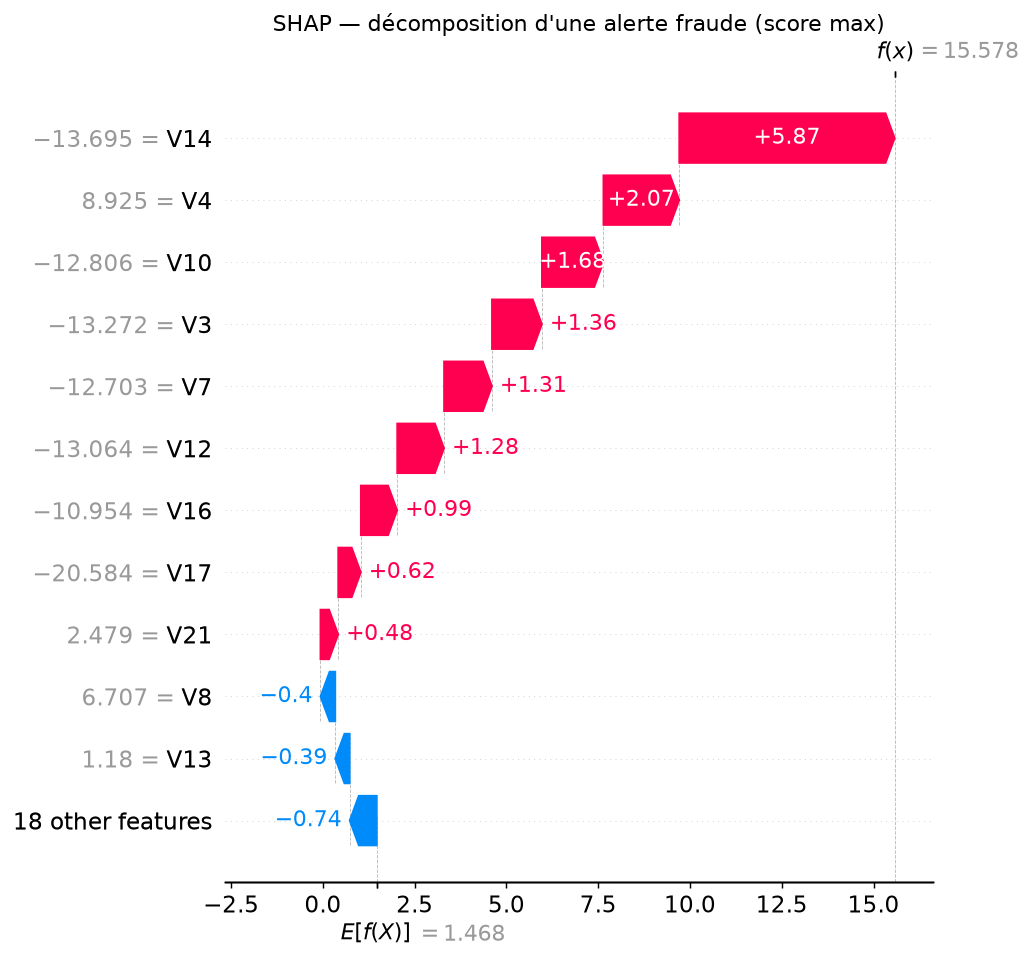

In [7]:
display(Image(ROOT / "reports" / "figures" / "shap_beeswarm.png", width=620))
display(Image(ROOT / "reports" / "figures" / "shap_waterfall_fraud.png",
              width=620))

**Lecture** — quatre composantes (V14, V4, V12, V10) portent l'essentiel du
signal : des valeurs basses de V14/V12/V10 et hautes de V4 tirent le score vers
la fraude. Le *waterfall* montre la décomposition d'une alerte réelle — la vue
« pourquoi cette transaction ? » d'un analyste. Les features étant des
composantes PCA anonymisées, l'interprétation reste structurelle ; sur données
brutes, on lirait directement commerçant, pays, heure, etc.

## 6. Conclusions & limites

**Conclusions**
- XGBoost + pondération de classe : **PR-AUC 0,86** sur 0,17 % de positifs.
- Le rééquilibrage (SMOTE & co) ne change pas le classement, seulement le
  compromis au seuil fixe — le levier décisionnel est le **seuil**, optimisé
  ici par un coût métier (–69 % de coût vs absence de modèle).
- Le non-supervisé ne remplace pas le supervisé mais couvre les fraudes
  nouvelles ; SHAP rend chaque alerte auditable.

**Limites**
- Deux jours de données d'une seule banque : aucune garantie de généralisation
  temporelle ou géographique ; un déploiement réel exige un réentraînement
  continu (dérive des patterns de fraude).
- Features PCA anonymisées → interprétabilité sémantique limitée.
- Coûts métier illustratifs (5 €/revue, plancher 50 €) ; la courbe de coût
  permet de rejouer l'analyse avec les vrais chiffres d'une équipe risque.
- Le split est aléatoire stratifié ; un split temporel strict (train passé /
  test futur) serait plus dur et plus réaliste.